# Predicting Heart Disease 



In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import mlflow
import mlflow.sklearn

# set random seed for reproducibility
np.random.seed(42)

# load dataset
data = pd.read_csv('data/train.csv')

# suffle the dataset
data = data.sample(frac=1).reset_index(drop=True)

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [ ]:
# rename column names for easier access
data.columns = [col.lower().replace(' ', '_') for col in data.columns]

# convert heart_disease to binary
data['heart_disease'] = data['heart_disease'].apply(lambda x: 0 if x == "Absence" else 1)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   age                      630000 non-null  int64  
 2   sex                      630000 non-null  int64  
 3   chest_pain_type          630000 non-null  int64  
 4   bp                       630000 non-null  int64  
 5   cholesterol              630000 non-null  int64  
 6   fbs_over_120             630000 non-null  int64  
 7   ekg_results              630000 non-null  int64  
 8   max_hr                   630000 non-null  int64  
 9   exercise_angina          630000 non-null  int64  
 10  st_depression            630000 non-null  float64
 11  slope_of_st              630000 non-null  int64  
 12  number_of_vessels_fluro  630000 non-null  int64  
 13  thallium                 630000 non-null  int64  
 14  hear

## 00. Split the data for testing

In [ ]:
# stratified split
from sklearn.model_selection import train_test_split

# Strafied split to maintain the distribution of the target variable
train_data, holdout_data = train_test_split(data,
                                        test_size=0.1, stratify=data["heart_disease"], random_state=42)


# save the split datasets
train_data.to_csv('data/train_split.csv', index=False)
holdout_data.to_csv('data/holdout_split.csv', index=False)

print("Data has been split and saved.")


Data has been split and saved.


In [5]:
# display first few rows of the dataset
train_data.head()

,id,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,heart_disease
318714,51395,51,0,1,140,229,0,2,163,0,0.0,2,0,3,Absence
509785,280337,57,0,2,140,256,0,2,159,0,0.0,1,0,3,Absence
267472,283500,52,1,4,140,231,1,2,144,0,1.6,2,0,7,Presence
25819,574883,44,1,1,120,208,0,2,175,0,0.0,1,0,3,Absence
45237,94624,52,1,1,120,234,0,2,161,0,0.0,1,0,3,Absence


heart_disease
Absence     55.165961
Presence    44.834039
Name: proportion, dtype: float64


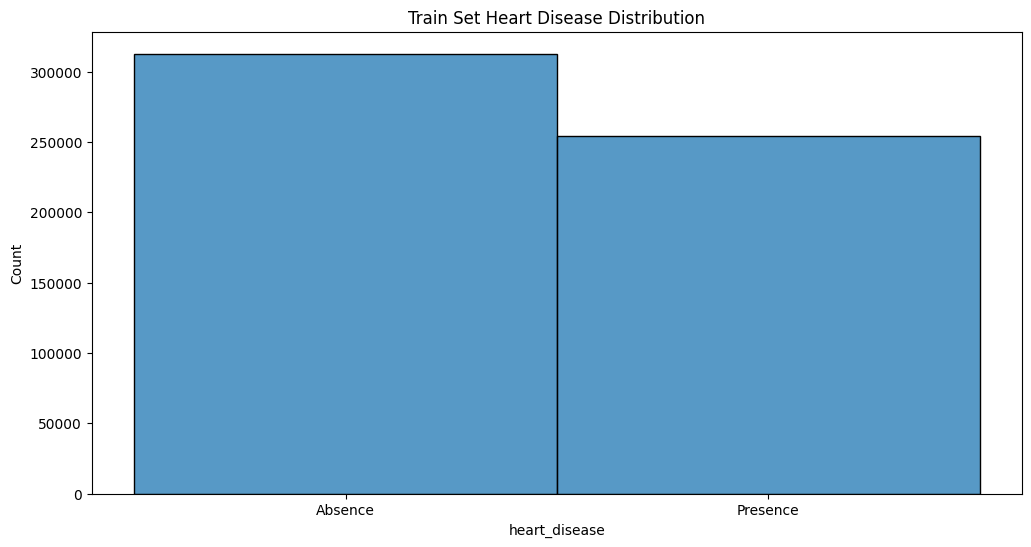

In [6]:
# check the balance of the target variable in the splits
plt.figure(figsize=(12, 6))
sns.histplot(train_data['heart_disease'], kde=False)
plt.title('Train Set Heart Disease Distribution')

# distribution of target variable in percentages
print(train_data['heart_disease'].value_counts(normalize=True) * 100)

## 01. EAD

In [8]:
train_data.describe()

,id,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,heart_disease
count,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000
mean,315033.428199,54.132480,0.714728,3.312665,130.495363,245.017277,0.079917,0.982547,152.809649,0.273901,0.716030,1.455660,0.450520,4.619302,0.448340
std,181842.082600,8.253996,0.451544,0.851686,14.976814,33.686785,0.271165,0.998795,19.113628,0.445959,0.948516,0.545072,0.797959,1.950039,0.497325
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,157617.750000,48.000000,0.000000,3.000000,120.000000,222.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,315039.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,0.000000
75%,472435.500000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [9]:
# check unique values for each feature
for col in train_data.columns:
    unique_values = train_data[col].nunique()
    print(f"{col}: {unique_values} unique values")

id: 567000 unique values
age: 42 unique values
sex: 2 unique values
chest_pain_type: 4 unique values
bp: 66 unique values
cholesterol: 149 unique values
fbs_over_120: 2 unique values
ekg_results: 3 unique values
max_hr: 92 unique values
exercise_angina: 2 unique values
st_depression: 66 unique values
slope_of_st: 3 unique values
number_of_vessels_fluro: 4 unique values
thallium: 3 unique values
heart_disease: 2 unique values


In [85]:
train_data.dtypes

id                           int64
age                          int64
sex                          int64
chest_pain_type              int64
bp                           int64
cholesterol                  int64
fbs_over_120                 int64
ekg_results                  int64
max_hr                       int64
exercise_angina              int64
st_depression              float64
slope_of_st                  int64
number_of_vessels_fluro      int64
thallium                     int64
heart_disease                int64
dtype: object

### Feature analysis

#### Numerical (continuous / quasi-continuous)
These are measurements; modeling them as continuous makes sense.

- `age`
- `bp`: 'blood pressure'; can have outliers / measurements errors
- `cholesterol`: often heavy right-tail; sometimes “0” or implausible values appear in dirty versions—worth checking
- `max_hr`: continuous; strong age dependency—think about interaction or nonlinearity
- `st_depression`: often called “oldpeak”; continuous; often skewed with many near-0; can be very informative

#### Numerical (Ordinal / count like)
- `slope_of_st` (3 values) — very strong signal for slope >1.
    - For trees: keep as int is fine.
    - For logistic: since the relationship is monotone across 1→2→3, then ordinal encoding is a reasonable simplification; can try one-hot.

- `number_of_vessels_fluro` (4 values) — monotone increasing ✅ and massive; very strong signal for >= 1; possibly 2 and 3 can be grouped together.
    - Trees: keep numeric 0–3.
    - Logistic: numeric is reasonable, but the jump 0→1 is much bigger than 1→2. So one-hot may fit better unless you add nonlinearity.
    - If you want to be systematic: fit logistic with (a) numeric vessels, (b) one-hot vessels; compare CV AUC/logloss.

#### Binary categorical
For many models, leaving them as 0/1 numeric is fine; conceptually they’re categorical.

- `sex` (2 values) — categorical (binary)
- `fbs_over_120` (2 values) — categorical (binary)
- `exercise_angina` (2 values) — categorical (binary)
    - exang=1: 80.6% | exang=0: 31.3%. This is extremely strong. One of the clearest risk markers in the dataset.
    - Large separation suggests it will be among top features in tree importance and logistic coefficients.
- `heart_disease`**TARGET** - keep as binary

#### Categorical / ordinal (encoded codes)
The numbers are codes, not distances; The spaces are not "meaningful amounts"
- `chest_pain_type` (4 values) — categorical (nominal in most datasets)
- `ekg_results` (3 values) — categorical (nominal codes); consider combining rare category 1 with 0 if improve CV
- `thallium` (3 values) — categorical (often a coded test result)


### Model-specific advice feature setup
- Tree/boosting (CatBoost/LightGBM/XGBoost):
    - You can keep ordinal/count columns as integers.
    - For nominal coded columns, either mark them as categorical (CatBoost) or one-hot/target-encode (LightGBM/XGB pipeline choice).

- Logistic regression baseline:
    - One-hot chest_pain_type, ekg_results, thallium (and often slope_of_st unless you’re confident it’s ordinal and monotone).
    - Treat number_of_vessels_fluro as numeric or one-hot; I’d try both and compare CV.


### Recommended encodings by model family (practical)

- CatBoost: mark chest_pain_type, ekg_results, thallium (and optionally slope_of_st) as categorical; keep vessels as numeric.

- LightGBM/XGBoost: one-hot chest_pain_type, ekg_results, thallium; keep vessels numeric; slope either one-hot or numeric (test).

- Logistic regression: one-hot chest_pain_type, ekg_results, thallium, and probably slope_of_st; keep vessels numeric and compare vs one-hot in CV.

In [100]:
cat_like = [
    "sex","fbs_over_120","exercise_angina",
    "chest_pain_type","ekg_results","slope_of_st",
    "number_of_vessels_fluro","thallium"
]
train_data[cat_like].apply(lambda s: sorted(s.unique()))


sex                              [0, 1]
fbs_over_120                     [0, 1]
exercise_angina                  [0, 1]
chest_pain_type            [1, 2, 3, 4]
ekg_results                   [0, 1, 2]
slope_of_st                   [1, 2, 3]
number_of_vessels_fluro    [0, 1, 2, 3]
thallium                      [3, 6, 7]
dtype: object

In [96]:
def categorical_summary(df, cat_cols, target="heart_disease", sort_by="event_rate", dropna=False):
    """
    Returns a dict {col: summary_df} where summary_df includes:
    - n: count
    - events: number of target==1
    - event_rate: events / n
    - log_odds: log(event_rate/(1-event_rate)) with smoothing
    """
    out = {}
    for col in cat_cols:
        tmp = df[[col, target]].copy()
        if not dropna:
            tmp[col] = tmp[col].astype("object")  # keeps categories clean; also keeps NaN as a level if present

        g = tmp.groupby(col, dropna=dropna)[target].agg(
            n="count",
            events="sum",
            event_rate="mean",
        ).reset_index()

        # smoothing to avoid inf when event_rate is 0 or 1
        eps = 1e-6
        p = np.clip(g["event_rate"].to_numpy(), eps, 1 - eps)
        g["log_odds"] = np.log(p / (1 - p))

        if sort_by is not None:
            g = g.sort_values(sort_by, ascending=False)

        out[col] = g

    return out

In [101]:
summaries = categorical_summary(train_data, cat_like, target="heart_disease", sort_by="event_rate")

for col, table in summaries.items():
    print("\n" + "="*60)
    print(col)
    print(table.to_string(index=False))


sex
 sex      n  events  event_rate  log_odds
   1 405251  225265    0.555865  0.224398
   0 161749   28944    0.178944 -1.523519

fbs_over_120
 fbs_over_120      n  events  event_rate  log_odds
            1  45313   22864    0.504579  0.018318
            0 521687  231345    0.443456 -0.227149

exercise_angina
 exercise_angina      n  events  event_rate  log_odds
               1 155302  125226    0.806339  1.426393
               0 411698  128983    0.313295 -0.784759

chest_pain_type
 chest_pain_type      n  events  event_rate  log_odds
               4 296248  206636    0.697510  0.835470
               3 177534   33845    0.190640 -1.445860
               2  67469   10953    0.162341 -1.640910
               1  25749    2775    0.107771 -2.113712

ekg_results
 ekg_results      n  events  event_rate  log_odds
           2 277955  155446    0.559249  0.238114
           1   1194     426    0.356784 -0.589350
           0 287851   98337    0.341625 -0.656063

slope_of_st
 slope_of_

In [102]:
def monotonicity_check(summary_df, col_name, increasing=True):
    # assumes the category column is in the first position
    s = summary_df.sort_values(col_name)["event_rate"].to_numpy()
    diffs = np.diff(s)
    ok = np.all(diffs >= 0) if increasing else np.all(diffs <= 0)
    return ok, s

for col in ["slope_of_st", "number_of_vessels_fluro"]:
    df_sum = summaries[col].copy()
    ok_inc, rates = monotonicity_check(df_sum, col, increasing=True)
    ok_dec, _ = monotonicity_check(df_sum, col, increasing=False)
    print(f"{col}: increasing={ok_inc}, decreasing={ok_dec}, rates_by_level={rates}")


slope_of_st: increasing=True, decreasing=False, rates_by_level=[0.2624135  0.69205811 0.72043706]
number_of_vessels_fluro: increasing=True, decreasing=False, rates_by_level=[0.3030802  0.73005466 0.89755079 0.89944843]


In [11]:
# revise the distribution of numerical features
train_data[numerical_features].describe()

,age,chest_pain_type,bp,cholesterol,max_hr,st_depression,number_of_vessels_fluro,heart_disease
count,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000,567000.000000
mean,54.132480,3.312665,130.495363,245.017277,152.809649,0.716030,0.450520,0.448340
std,8.253996,0.851686,14.976814,33.686785,19.113628,0.948516,0.797959,0.497325
min,29.000000,1.000000,94.000000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,48.000000,3.000000,120.000000,222.000000,142.000000,0.000000,0.000000,0.000000
50%,54.000000,4.000000,130.000000,243.000000,157.000000,0.100000,0.000000,0.000000
75%,60.000000,4.000000,140.000000,269.000000,166.000000,1.400000,1.000000,1.000000
max,77.000000,4.000000,200.000000,564.000000,202.000000,6.200000,3.000000,1.000000


In [12]:
train_data.head()

,id,age,sex,chest_pain_type,bp,cholesterol,fbs_over_120,ekg_results,max_hr,exercise_angina,st_depression,slope_of_st,number_of_vessels_fluro,thallium,heart_disease
318714,51395,51,0,1,140,229,0,2,163,0,0.0,2,0,3,0
509785,280337,57,0,2,140,256,0,2,159,0,0.0,1,0,3,0
267472,283500,52,1,4,140,231,1,2,144,0,1.6,2,0,7,1
25819,574883,44,1,1,120,208,0,2,175,0,0.0,1,0,3,0
45237,94624,52,1,1,120,234,0,2,161,0,0.0,1,0,3,0


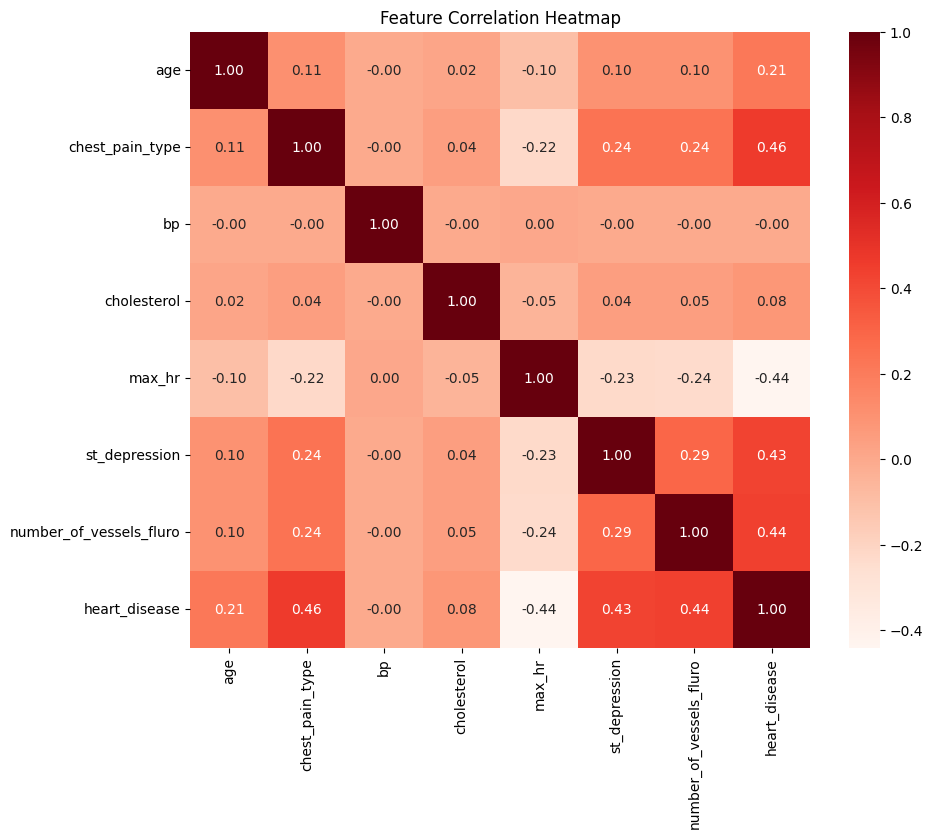

In [18]:
# plot correlation heatmap
plt.figure(figsize=(10, 8))
corr = train_data[numerical_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Reds')
plt.title('Feature Correlation Heatmap')
plt.show()

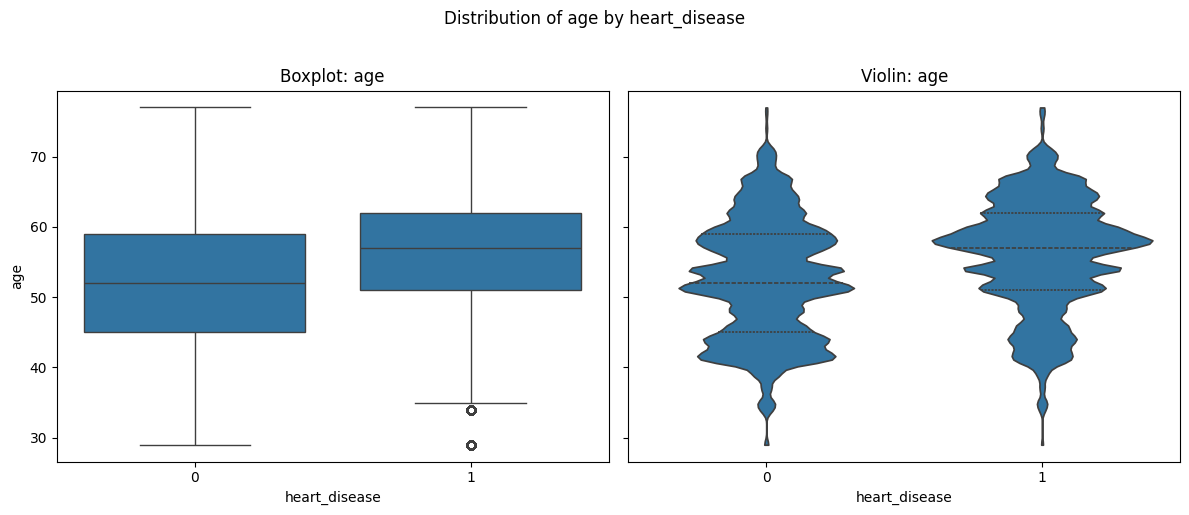

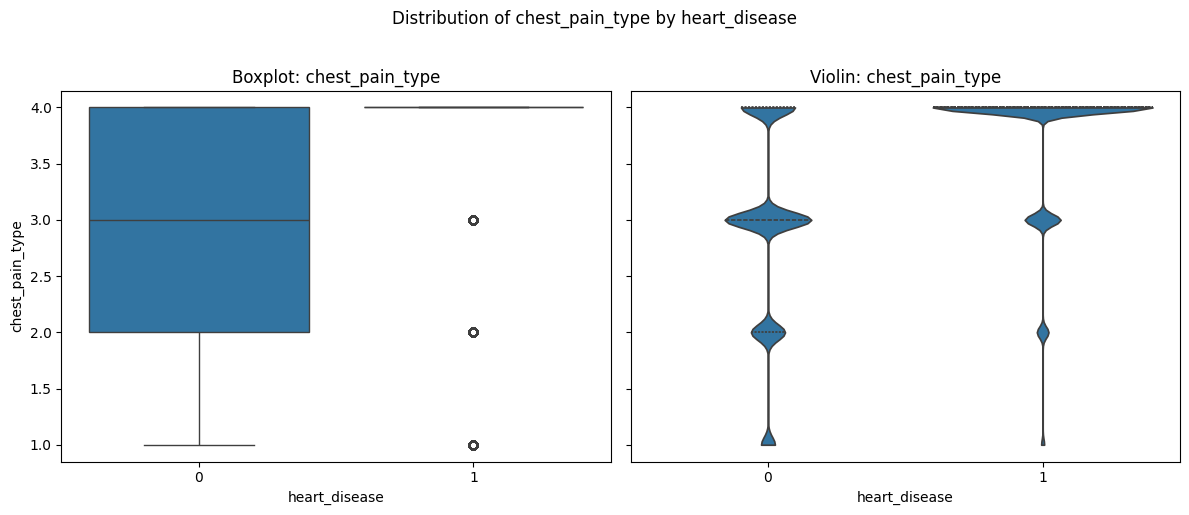

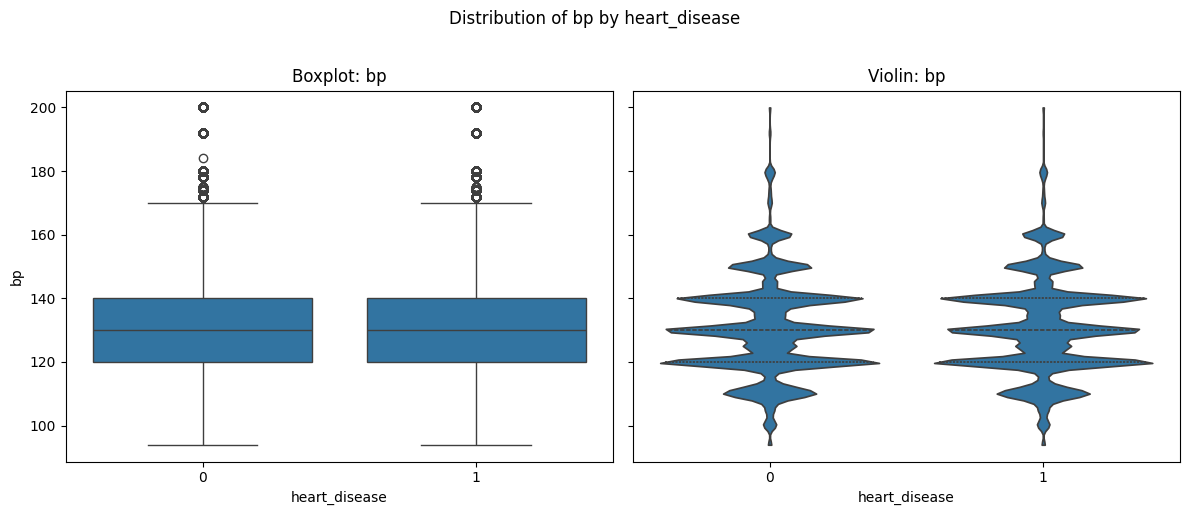

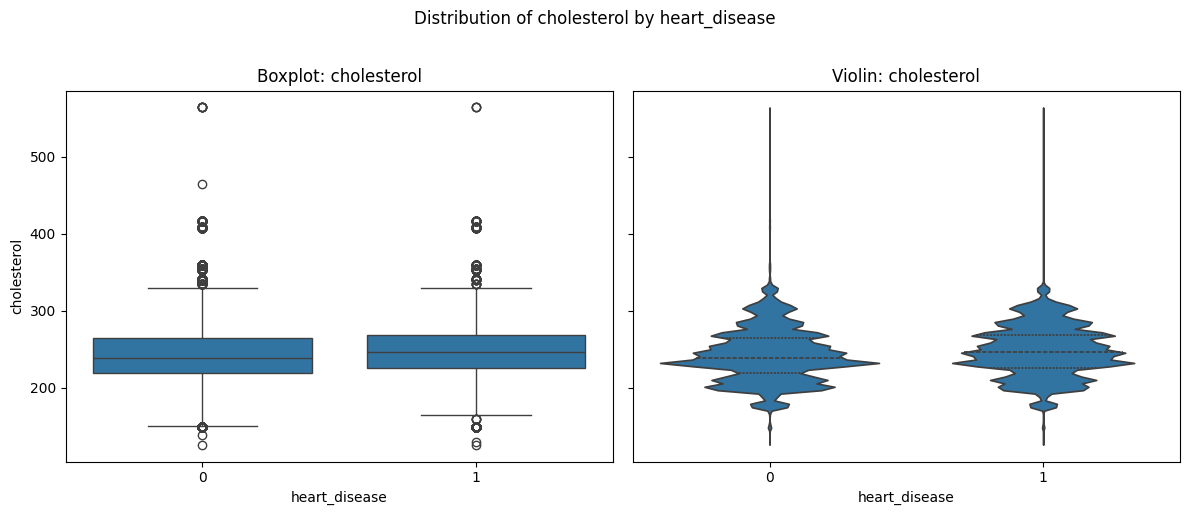

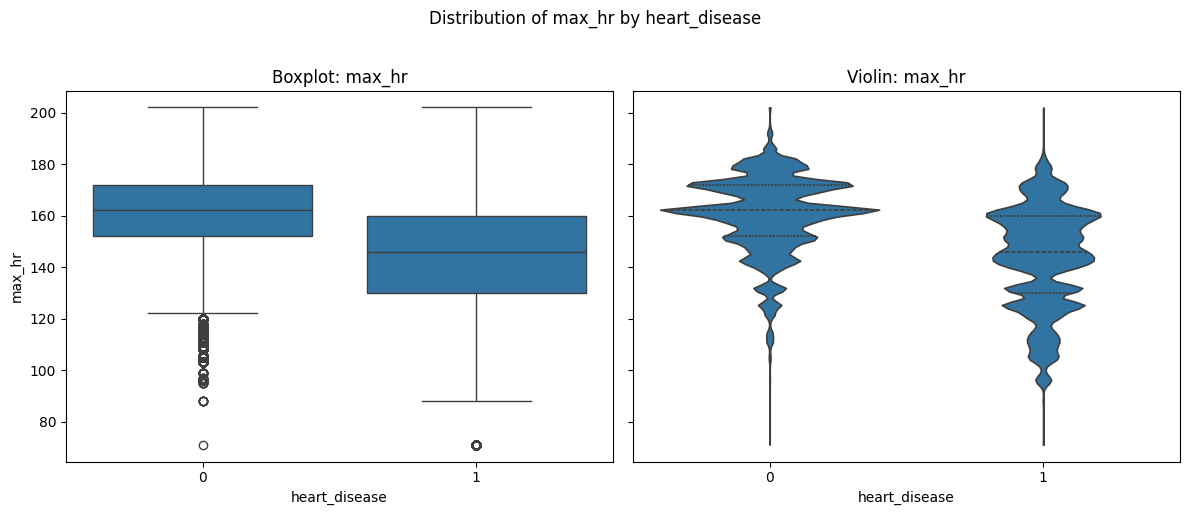

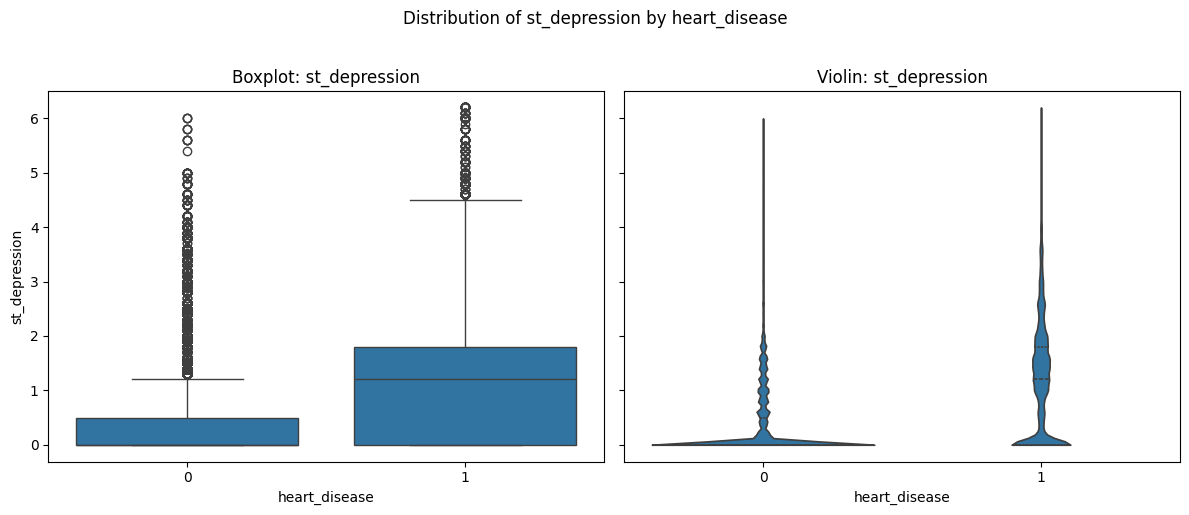

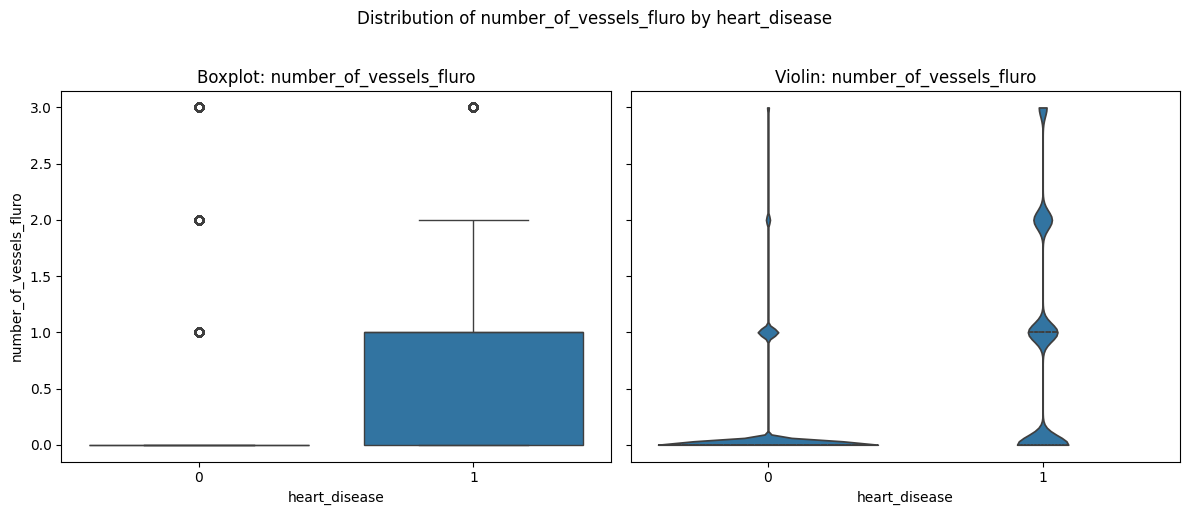

In [29]:
# display numerical features against target variable
target = "heart_disease"
order = [0, 1]

for feature in [f for f in numerical_features if f != 'heart_disease']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Boxplot
    sns.boxplot(
        ax=axes[0],
        data=train_data,
        x=target,
        y=feature,
        order=order
    )
    axes[0].set_title(f"Boxplot: {feature}")
    axes[0].set_xlabel(target)
    axes[0].set_ylabel(feature)

    # Violin plot
    sns.violinplot(
        ax=axes[1],
        data=train_data,
        x=target,
        y=feature,
        order=order,
        cut=0,          # don't extend beyond data range
        inner="quartile" # show quartiles inside violin
    )
    axes[1].set_title(f"Violin: {feature}")
    axes[1].set_xlabel(target)
    axes[1].set_ylabel("")  # sharey=True, so avoid repeating label

    fig.suptitle(f"Distribution of {feature} by {target}", y=1.02)
    plt.tight_layout()
    plt.show()

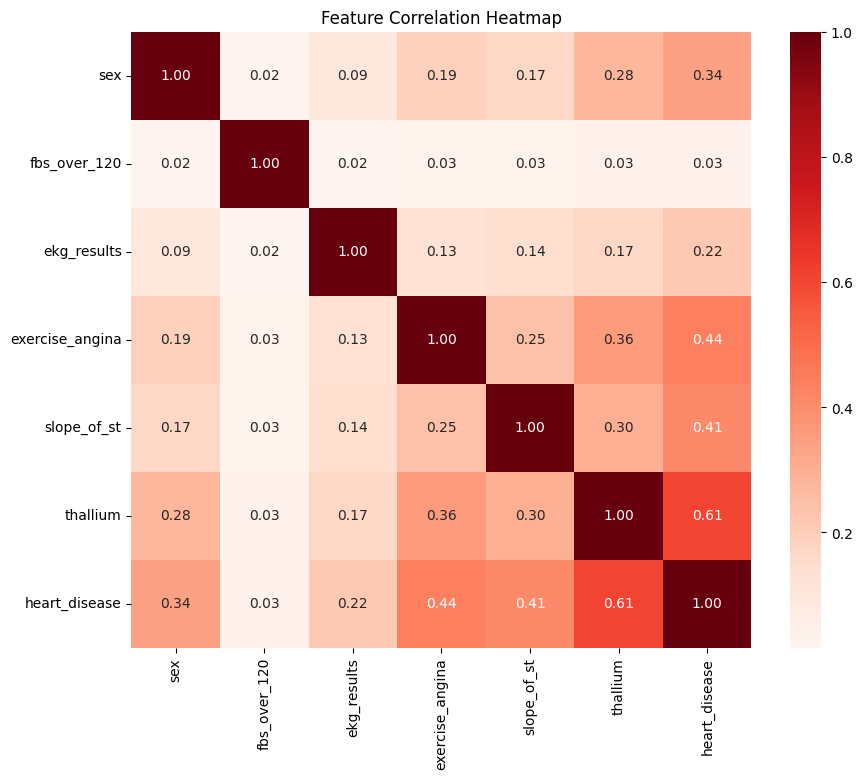

In [32]:
# moving on to the categorical features
plt.figure(figsize=(10, 8))
corr = train_data[categorical_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Reds')
plt.title('Feature Correlation Heatmap')
plt.show()

In [33]:
# use information theory to find the most important categorical features
# might take a few seconds to run
from sklearn.feature_selection import mutual_info_regression

categorical_data = train_data[categorical_features].apply(lambda x: x.astype('category').cat.codes)

mi_scores = mutual_info_regression(categorical_data, train_data['heart_disease'])
mi_scores = pd.Series(mi_scores, index=categorical_features).sort_values(ascending=False)

print("Mutual Information Scores for Categorical Features:")
print(mi_scores)

Mutual Information Scores for Categorical Features:
heart_disease      0.686935
thallium           0.195408
exercise_angina    0.102574
slope_of_st        0.094832
sex                0.064653
ekg_results        0.025456
fbs_over_120       0.002249
dtype: float64


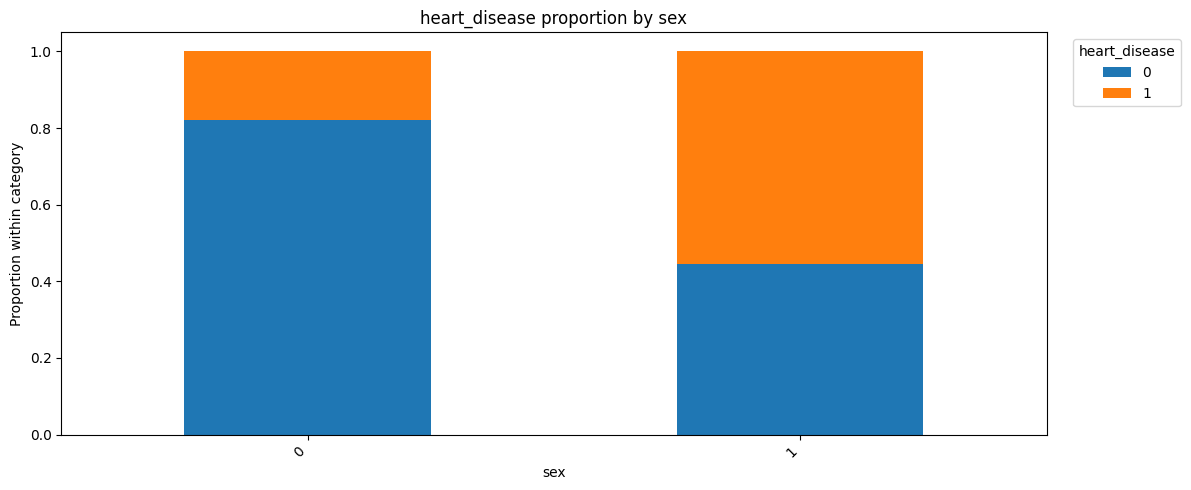

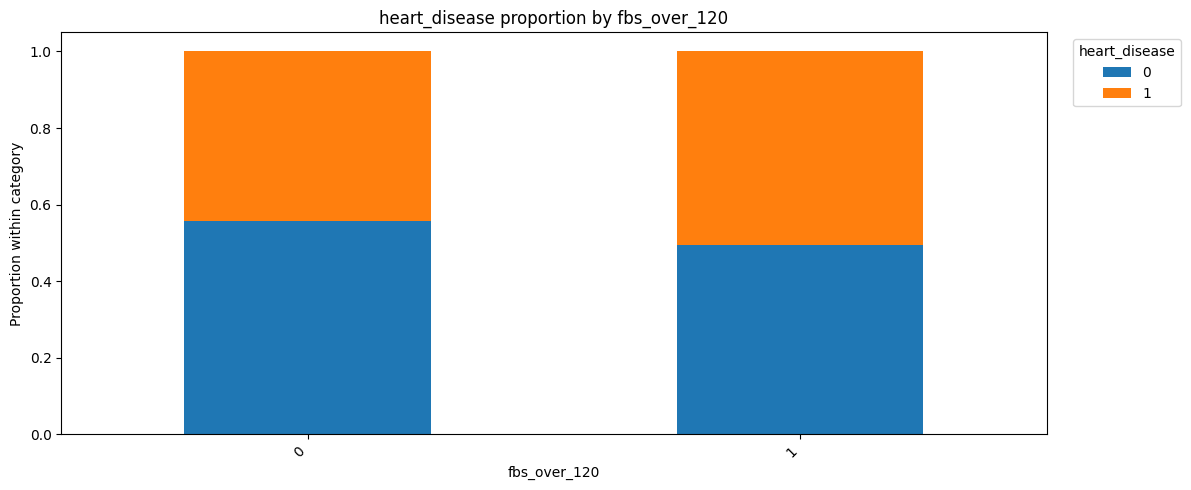

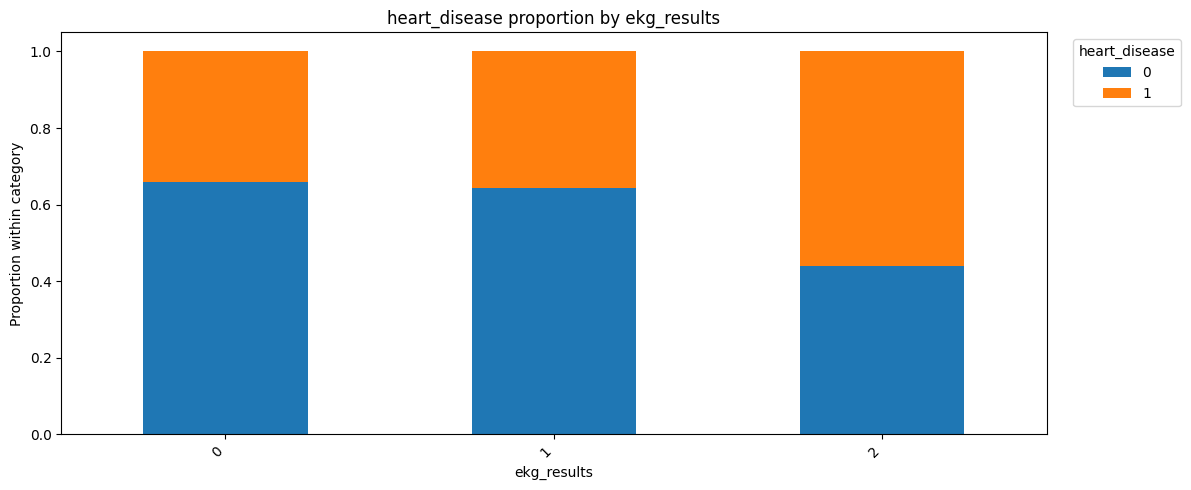

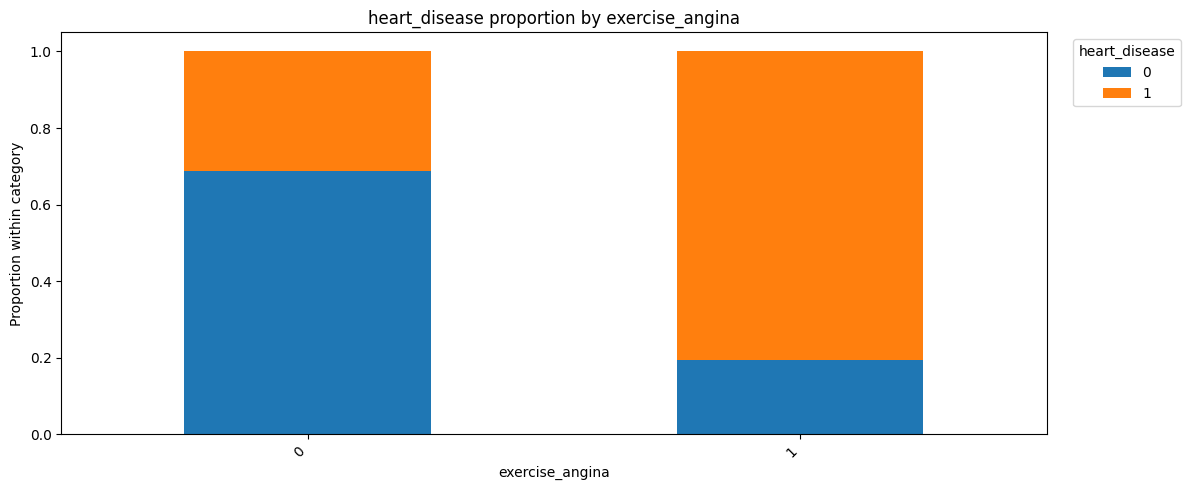

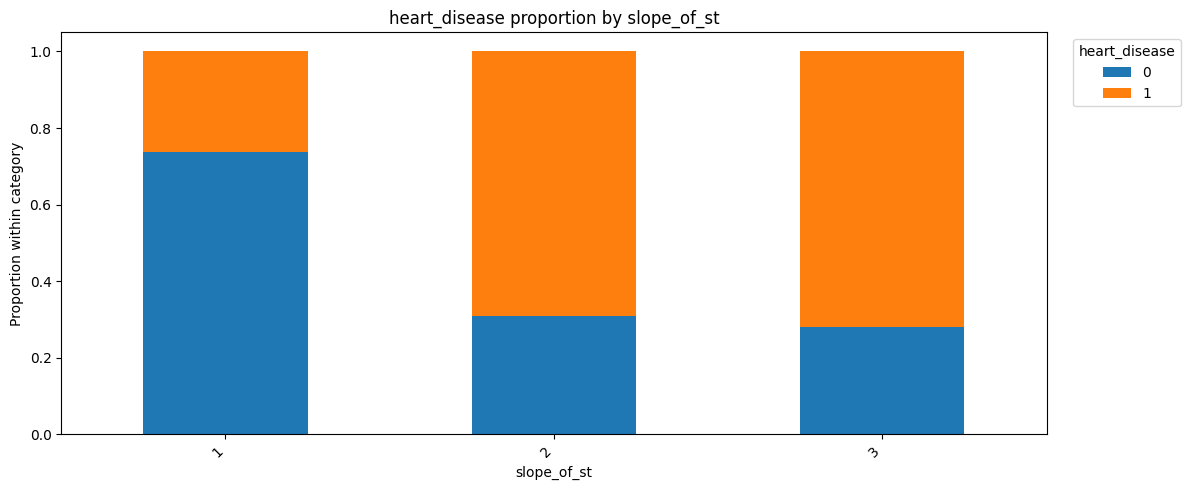

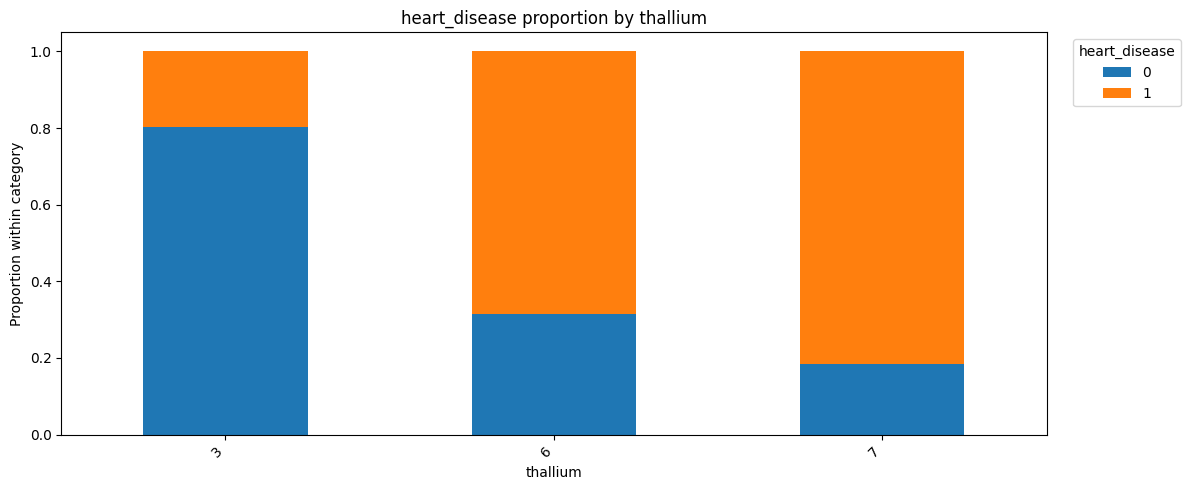

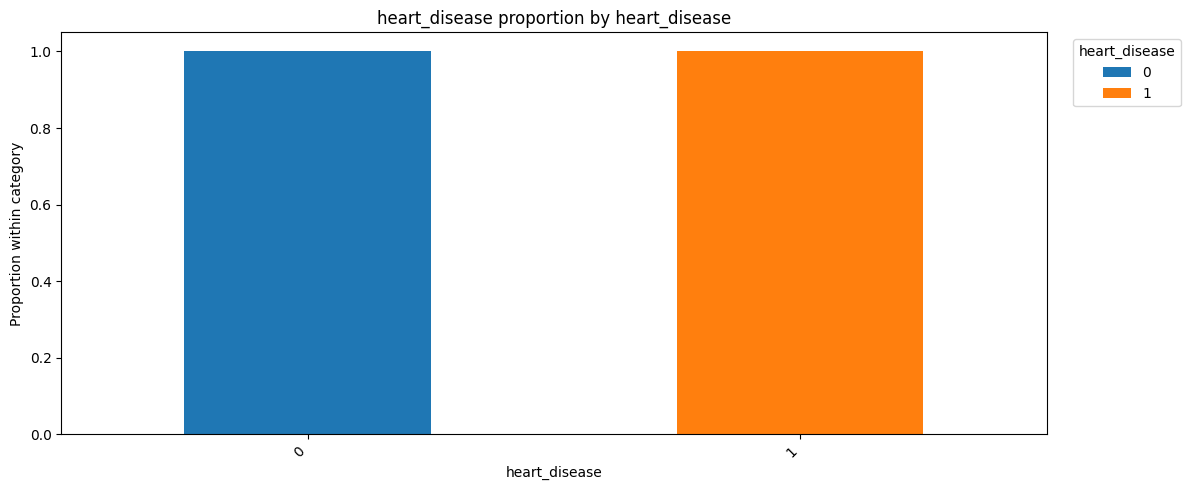

In [35]:
target = "heart_disease"

for feature in categorical_features:
    ct = pd.crosstab(train_data[feature], train_data[target], normalize="index")  # proportions per category

    ax = ct.plot(kind="bar", stacked=True, figsize=(12, 5))
    ax.set_title(f"{target} proportion by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Proportion within category")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=target, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

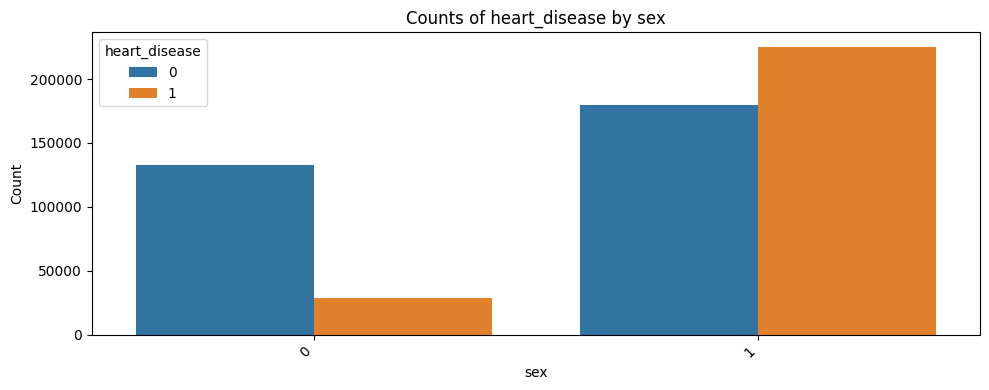

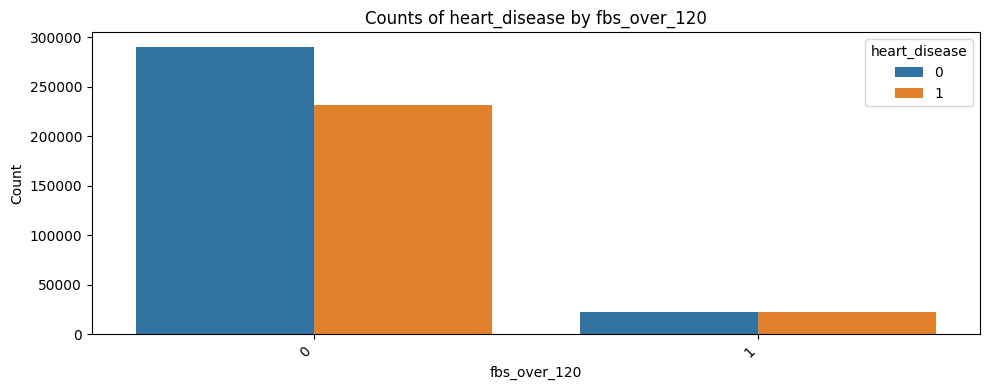

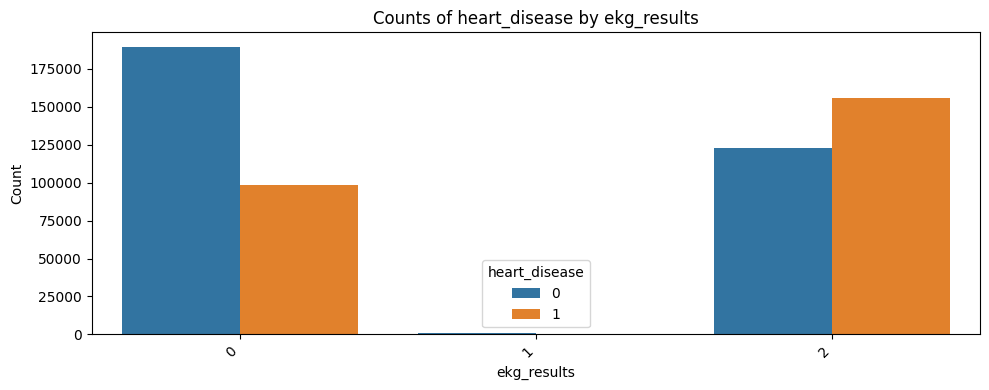

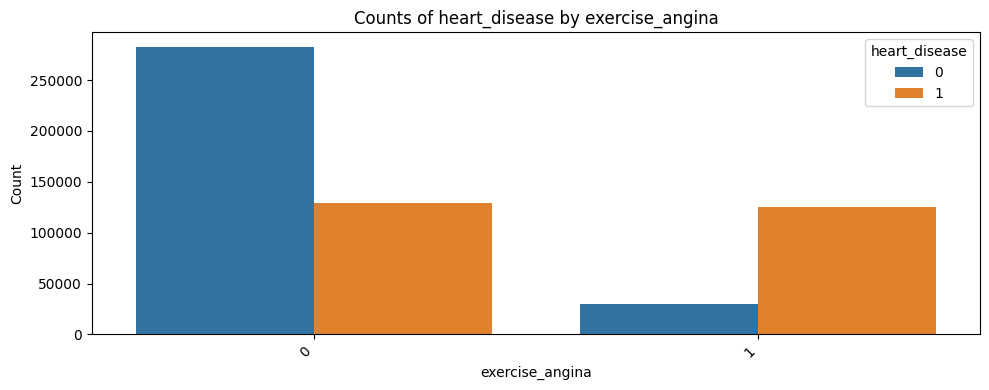

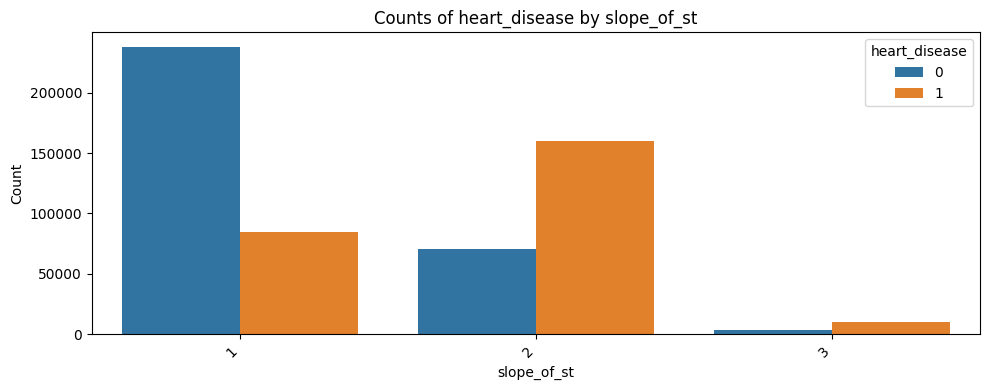

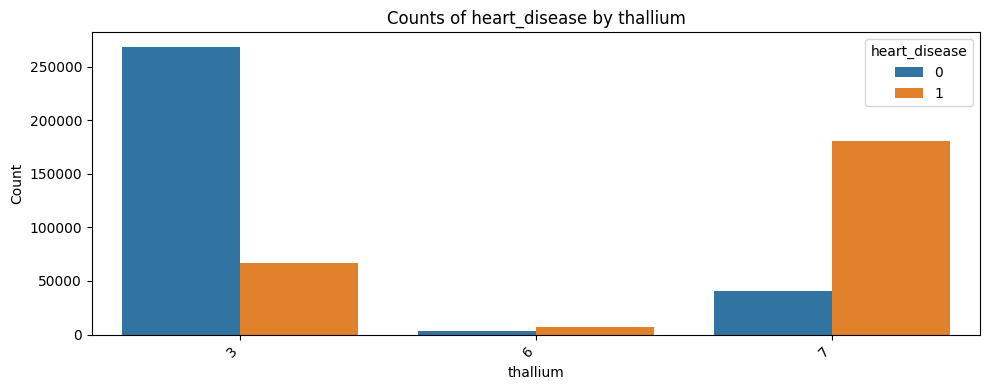

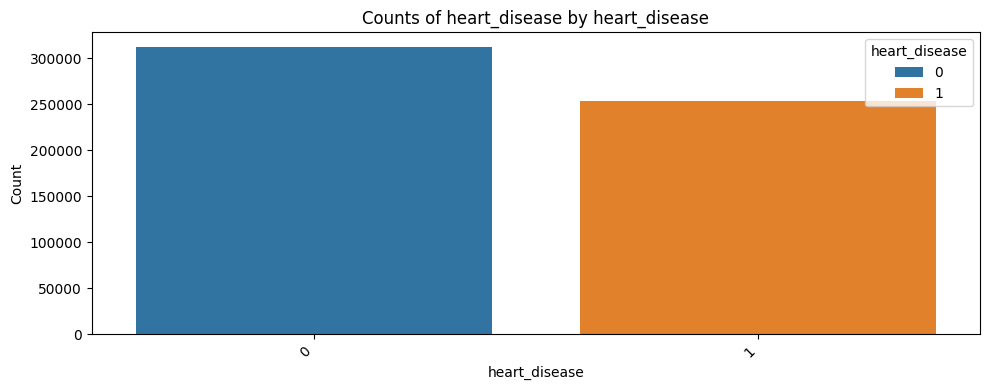

In [39]:
target = "heart_disease"

for feature in categorical_features:
    plt.figure(figsize=(10, 4))
    sns.countplot(
        data=train_data,
        x=feature,
        hue=target
    )
    plt.title(f"Counts of {target} by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=target)
    plt.tight_layout()
    plt.show()

## Notes

- **Numerical variables with higher correlation:** chest_pain_type, st_depression, number_of_vessels_fluro

- **Numerical variables with low correlation:** bp, cholesterol


- Risk factors:
    - sex (being 1)
    - chest pain = 4
    - exercise_angina = 1
    - ekg_results = 2
    - slope of > 1
    - number_of_vessels_fluro =1, and/or higher weight if 2 or 3
    - thallium = 7 is high risk; thallium=3 is low risk


```py 
+1 if sex==1
+1 if exercise_angina==1
+1 if ekg_results==2
+1 if slope_of_st in {2,3} (i.e., >1)
+0/+1/+2/+3 for number_of_vessels_fluro (use the count itself; don’t overthink)
+1 if thallium in {6,7} and optionally +2 if thallium==7
+1 if chest_pain_type==4
```




## Feature Engineering

In [115]:
def add_engineered_features(
    df: pd.DataFrame,
    *,
    drop_id: bool = True,
    make_bins: bool = False,
    n_bins: int = 10,
) -> pd.DataFrame:
    """
    Create a copy of df with engineered features added.

    Assumptions (based on your dataset):
      - chest_pain_type in {1,2,3,4}
      - ekg_results in {0,1,2}
      - slope_of_st in {1,2,3}
      - number_of_vessels_fluro in {0,1,2,3}
      - thallium in {3,6,7}
      - binaries: sex, fbs_over_120, exercise_angina in {0,1}
      - continuous: age, bp, cholesterol, max_hr, st_depression

    Parameters
    ----------
    drop_id : bool
        If True, drops 'id' column if present.
    make_bins : bool
        If True, adds quantile-binned versions of age/max_hr/st_depression.
        Note: bins should be fit on train only to avoid leakage; for now this is exploratory.
    n_bins : int
        Number of quantile bins if make_bins=True.

    Returns
    -------
    pd.DataFrame
        New dataframe with engineered columns appended.
    """
    X = df.copy()

    if drop_id and "id" in X.columns:
        X = X.drop(columns=["id"])

    # --- Safety: ensure required columns exist before creating features
    required = {
        "sex", "chest_pain_type", "exercise_angina", "ekg_results",
        "slope_of_st", "number_of_vessels_fluro", "thallium",
        "age", "max_hr", "st_depression"
    }
    missing = required - set(X.columns)
    if missing:
        raise ValueError(f"Missing columns required for feature engineering: {sorted(missing)}")

    # --- Core flags
    X["cp4"] = (X["chest_pain_type"] == 4).astype(np.int8)
    X["ekg2"] = (X["ekg_results"] == 2).astype(np.int8)
    X["slope_gt_1"] = (X["slope_of_st"] > 1).astype(np.int8)
    X["vessels_ge_1"] = (X["number_of_vessels_fluro"] >= 1).astype(np.int8)
    X["vessels_ge_2"] = (X["number_of_vessels_fluro"] >= 2).astype(np.int8)
    X["thallium_abnormal"] = X["thallium"].isin([6, 7]).astype(np.int8)
    X["thallium_7_flag"] = (X["thallium"] == 7).astype(np.int8)
    X["sex_male_flag"] = (X["sex"] == 1).astype(np.int8)  # naming explicit; keep original too
    X["fbs_over_120_flag"] = (X["fbs_over_120"] == 1).astype(np.int8)
    X["exercise_angina_flag"] = (X["exercise_angina"] == 1).astype(np.int8)


    # --- Risk scores
    # Simple: unweighted sum of high-risk flags
    X["risk_score_simple"] = (
        X["sex_male_flag"]
        + X["cp4"]
        + X["exercise_angina"].astype(np.int8)
        + X["ekg2"]
        + X["slope_gt_1"]
        + X["vessels_ge_1"]
        + X["thallium_abnormal"]
    ).astype(np.int16)

    # Weighted: vessels count + thallium weight + a few strong flags
    th_weight = np.select(
        [X["thallium"] == 7, X["thallium"] == 6],
        [2, 1],
        default=0
    ).astype(np.int8)

    X["risk_score_weighted"] = (
        X["number_of_vessels_fluro"].astype(np.int16)
        + th_weight.astype(np.int16)
        + X["cp4"].astype(np.int16)
        + X["exercise_angina"].astype(np.int16)
        + X["slope_gt_1"].astype(np.int16)
    ).astype(np.int16)

    # --- Interactions (cheap but often helpful for GBDT)
    X["vessels_x_thallium7"] = (
        X["number_of_vessels_fluro"].astype(np.int16) * X["thallium_7_flag"].astype(np.int16)
    ).astype(np.int16)

    X["cp4_and_exang"] = (X["cp4"].astype(bool) & (X["exercise_angina"] == 1)).astype(np.int8)

    X["stdep_x_slopegt1"] = X["st_depression"] * X["slope_gt_1"]

    # Age-adjusted-ish: max_hr / age (avoid divide-by-zero just in case)
    X["maxhr_age_ratio"] = X["max_hr"] / (X["age"].replace(0, np.nan))
    X["maxhr_age_ratio"] = X["maxhr_age_ratio"].fillna(0.0).astype(np.float32)

    # Nonlinear transform for skew
    X["st_depression_log1p"] = np.log1p(X["st_depression"]).astype(np.float32)

    # Optional: quantile binning for exploration (fit on train only in a real pipeline)
    if make_bins:
        for col in ["age", "max_hr", "st_depression"]:
            X[f"{col}_qbin"] = pd.qcut(X[col], q=n_bins, duplicates="drop")

    return X


## Kaggle submission file

In [78]:
def create_submission_file(numeric_features, categorical_features, model, filename='submission.csv'):
    X_kaggle = pd.read_csv("data/test.csv")
    X_kaggle.columns = [col.lower().replace(' ', '_') for col in X_kaggle.columns]
    X_kaggle_processed = X_kaggle[numeric_features + categorical_features]

    y_kaggle = model.predict_proba(X_kaggle_processed)[:, 1]  # Get probability of positive class

    submission = pd.DataFrame({
        'id': X_kaggle['id'],
        'Heart Disease': y_kaggle
    })
    submission.to_csv(filename, index=False)
    print(f"Submission file '{filename}' created.")

In [109]:
create_submission_file(numeric_features, categorical_features, model_lr, filename='sub/submission_lr_dummy.csv')

Submission file 'sub/submission_lr_dummy.csv' created.


## First models

### Random Forest

Simple dummy model, no feature engineering.

General score: `CV ROC-AUC: mean=0.9472 std=0.0009 Holdout ROC-AUC: 0.9475` 

In [75]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

target = "heart_disease"

# Choose feature groups (based on your list)
numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression"]
categorical_features = [
    "sex", "chest_pain_type", "fbs_over_120", "ekg_results",
    "exercise_angina", "slope_of_st", "number_of_vessels_fluro", "thallium"
]

X_train = train_data[numeric_features + categorical_features]
y_train = train_data[target].astype(int)

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# Model
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"  # helpful if imbalance exists
)

model_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

# CV on training (not holdout)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"CV ROC-AUC: mean={cv_auc.mean():.4f} std={cv_auc.std():.4f}")

# Fit on full train split and evaluate once on holdout
model_rf.fit(X_train, y_train)

# Evaluate on holdout data
X_holdout = holdout_data[numeric_features + categorical_features]
y_holdout = holdout_data[target].astype(int)

y_pred_proba = model_rf.predict_proba(X_holdout)[:, 1]
auc_score = roc_auc_score(y_holdout, y_pred_proba)
print(f"Holdout ROC-AUC: {auc_score:.4f}")

# Print classification report
y_pred = model_rf.predict(X_holdout)
print("\nClassification Report:")
print(classification_report(y_holdout, y_pred))

CV ROC-AUC: mean=0.9472 std=0.0009
Holdout ROC-AUC: 0.9475

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     34755
           1       0.87      0.86      0.87     28245

    accuracy                           0.88     63000
   macro avg       0.88      0.88      0.88     63000
weighted avg       0.88      0.88      0.88     63000



In [77]:
y_pred_proba

array([0.586, 0.056, 0.99 , ..., 0.1  , 0.998, 0.994])

### GBC - V1

In this version, we have a 'dummy model' and no feature engineering. 
This is just to work as a basis for further improvement. 

General score: `CV ROC-AUC: mean=0.9542 std=0.0007, Holdout ROC-AUC: 0.9547`

In [103]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

target = "heart_disease"

# Note to self: before we treated slope_of_st and number_of_vessels_fluro as categorical features, CV ROC-AUC: mean=0.9542 std=0.0007, Holdout ROC-AUC: 0.9547

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression", "slope_of_st", "number_of_vessels_fluro" ]
categorical_features = [
    "sex", "chest_pain_type", "fbs_over_120", "ekg_results",
    "exercise_angina", "thallium"
]

X_train = train_data[numeric_features + categorical_features]
y_train = train_data[target].astype(int)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # not needed for this dataset, but good practice
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # not needed for this dataset, but good practice
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,        # depth of individual trees
    subsample=0.8       # stochastic boosting
)

model_gbc = Pipeline(steps=[
    ("preprocess", preprocess),
    ("gb", gb)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model_gbc, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"CV ROC-AUC: mean={cv_auc.mean():.4f} std={cv_auc.std():.4f}")

model_gbc.fit(X_train, y_train)

CV ROC-AUC: mean=0.9542 std=0.0007


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'bp', 'cholesterol',
                                                   'max_hr', 'st_depression',
                                                   'slope_of_st',
                                                   'number_of_vessels_fluro']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'chest_pain_type',
                                                   'fbs_over_120',
                                                   'ekg_results',
                                                   'exercise_angina',
                                                   'thallium'])])),
                ('gb',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [104]:
X_test = holdout_data[numeric_features + categorical_features]
y_test = holdout_data[target].astype(int)

y_pred_test = model_gbc.predict(X_test)
y_pred_proba_test = model_gbc.predict_proba(X_test)[:, 1]

print(f"Holdout ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")
print(classification_report(y_test, y_pred_test))

Holdout ROC-AUC: 0.9547
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     34755
           1       0.88      0.87      0.87     28245

    accuracy                           0.89     63000
   macro avg       0.89      0.89      0.89     63000
weighted avg       0.89      0.89      0.89     63000



In [105]:
# analyse feature importances
feature_names_num = numeric_features
ohe = model_gbc.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])
importances = model_gbc.named_steps["gb"].feature_importances_
feature_importances_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)
print(feature_importances_df)

                    feature  importance
20               thallium_3    0.481466
12        chest_pain_type_4    0.167920
3                    max_hr    0.077961
6   number_of_vessels_fluro    0.076069
5               slope_of_st    0.046749
4             st_depression    0.042566
18        exercise_angina_0    0.037719
19        exercise_angina_1    0.016454
8                     sex_1    0.015613
22               thallium_7    0.014954
0                       age    0.009132
7                     sex_0    0.008002
17            ekg_results_2    0.003338
2               cholesterol    0.001311
9         chest_pain_type_1    0.000439
1                        bp    0.000229
11        chest_pain_type_3    0.000043
15            ekg_results_0    0.000025
21               thallium_6    0.000008
14           fbs_over_120_1    0.000000
13           fbs_over_120_0    0.000000
10        chest_pain_type_2    0.000000
16            ekg_results_1    0.000000


### GBC - V2

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

target = "heart_disease"

numeric_features_base = [ #"age", 
#"bp", 
"cholesterol", "max_hr", 
"st_depression", 
#"slope_of_st", 
#"number_of_vessels_fluro"
]
categorical_features_base = [
    #"sex", 
    #"chest_pain_type", 
    # "fbs_over_120", 
    #"ekg_results",
    #"exercise_angina", 
    #"thallium"
]

engineered_numeric = [
    #"risk_score_simple",
    "risk_score_weighted",
    #"vessels_x_thallium7",
    #"stdep_x_slopegt1",
    "maxhr_age_ratio",
    #"st_depression_log1p",
]
engineered_categorical = [
    #"cp4",
    #"ekg2",
    #"slope_gt_1",
    #"vessels_ge_1",
    #"vessels_ge_2",
    #"thallium_abnormal",
    #"thallium_7_flag",

    #"cp4_and_exang",
]

engineered_binary = [
    "sex_male_flag",
    "exercise_angina_flag",
    "fbs_over_120_flag"
]

numeric_features = numeric_features_base + engineered_numeric + engineered_binary
categorical_features = categorical_features_base + engineered_categorical

# IMPORTANT: do NOT set feature_names_out="one-to-one" because we add columns
fe_step = FunctionTransformer(
    lambda df: add_engineered_features(df, drop_id=True, make_bins=False),
    validate=False
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

# GBC needs dense -> set sparse_output=False
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

gb = GradientBoostingClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8
)

model_gbc = Pipeline(steps=[
    ("fe", fe_step),
    ("preprocess", preprocess),
    ("gb", gb)
])

X_train = train_data.drop(columns=[target])   # keep raw; pipeline engineers features
y_train = train_data[target].astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model_gbc, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"CV ROC-AUC: mean={cv_auc.mean():.4f} std={cv_auc.std():.4f}")

model_gbc.fit(X_train, y_train)


CV ROC-AUC: mean=0.9535 std=0.0008


Pipeline(steps=[('fe',
                 FunctionTransformer(func=<function <lambda> at 0x141304900>)),
                ('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['bp', 'cholesterol',
                                                   'max_hr', 'st_depression',
                                                   'number_of_vessels_fluro',
                                                   'risk_score_weighted',
                                                   'maxhr_age_ratio',
                                                   'st_depression_log1p',
                                                   'sex_male_flag',
                                                   'exercise_angina_flag',
                                                   'fbs_over_120_flag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['chest_pain_type'])],
                                   verbose_feature_names_out=False)),
                ('gb',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])

In [121]:
# analyse feature importances
feature_names_num = numeric_features
ohe = model_gbc.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])
importances = model_gbc.named_steps["gb"].feature_importances_
feature_importances_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)
print(feature_importances_df)

                    feature  importance
5       risk_score_weighted    0.850322
2                    max_hr    0.051110
14        chest_pain_type_4    0.027895
6           maxhr_age_ratio    0.027779
8             sex_male_flag    0.018779
3             st_depression    0.011353
7       st_depression_log1p    0.007587
9      exercise_angina_flag    0.001712
1               cholesterol    0.001461
4   number_of_vessels_fluro    0.001250
11        chest_pain_type_1    0.000400
0                        bp    0.000307
13        chest_pain_type_3    0.000025
12        chest_pain_type_2    0.000017
10        fbs_over_120_flag    0.000003


### Logistic Regression

Simple dummy model, no feature engineering or parameter tunning.

General score: `CV ROC-AUC: mean=0.9529 std=0.0004, Holdout ROC-AUC: 0.9533`

In [107]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


all_data = pd.read_csv('data/train.csv')
all_data.columns = [col.lower().replace(' ', '_') for col in all_data.columns]

# convert heart_disease to binary
all_data['heart_disease'] = all_data['heart_disease'].apply(lambda x: 0 if x == "Absence" else 1)

target = "heart_disease"

numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression"]
categorical_features = [
    "sex", "chest_pain_type", "fbs_over_120", "ekg_results",
    "exercise_angina", "slope_of_st", "number_of_vessels_fluro", "thallium"
]

X_train = all_data[numeric_features + categorical_features]
y_train = all_data[target].astype(int)

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())  # important for logistic regression
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# Model (linear classifier)
logreg = LogisticRegression(
    max_iter=5000,
    solver="liblinear",     # stable for small/medium datasets
    class_weight="balanced",# use if imbalance; remove if not needed
    random_state=42
)

model_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("logreg", logreg)
])

# CV on training
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"CV ROC-AUC: mean={cv_auc.mean():.4f} std={cv_auc.std():.4f}")

# Fit on full train split
model_lr.fit(X_train, y_train)


CV ROC-AUC: mean=0.9473 std=0.0004


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bp', 'cholesterol',
                                                   'max_hr', 'st_depression']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'chest_pain_type',
                                                   'fbs_over_120',
                                                   'ekg_results',
                                                   'exercise_angina',
                                                   'slope_of_st',
                                                   'number_of_vessels_fluro',
                                                   'thallium'])])),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42, solver='liblinear'))])

In [108]:
X_test = holdout_data[numeric_features + categorical_features]
y_test = holdout_data[target].astype(int)

y_pred_test = model_lr.predict(X_test)
y_pred_proba_test = model_lr.predict_proba(X_test)[:, 1]

print(f"Holdout ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")
print(classification_report(y_test, y_pred_test))

Holdout ROC-AUC: 0.9533
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     34755
           1       0.87      0.88      0.87     28245

    accuracy                           0.89     63000
   macro avg       0.88      0.89      0.88     63000
weighted avg       0.89      0.89      0.89     63000



In [112]:
# check the feature importances
numeric_features = ["age", "bp", "cholesterol", "max_hr", "st_depression"]
categorical_features = [
    "sex", "chest_pain_type", "fbs_over_120", "ekg_results",
    "exercise_angina", "slope_of_st", "number_of_vessels_fluro", "thallium"
]

feature_names_num = numeric_features
ohe = model_lr.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
feature_names_cat = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([feature_names_num, feature_names_cat])
coefs = model_lr.named_steps["logreg"].coef_[0]
feature_importances_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=False)
print(feature_importances_df)

                      feature  coefficient
10          chest_pain_type_4     1.463831
21  number_of_vessels_fluro_0    -1.171770
25                 thallium_3    -1.085183
27                 thallium_7     0.879220
3                      max_hr    -0.834527
7           chest_pain_type_1    -0.782827
24  number_of_vessels_fluro_3     0.743124
23  number_of_vessels_fluro_2     0.694285
17          exercise_angina_1     0.667720
6                       sex_1     0.608692
18              slope_of_st_1    -0.550810
16          exercise_angina_0    -0.511568
5                       sex_0    -0.452540
4               st_depression     0.442118
15              ekg_results_2     0.365866
26                 thallium_6     0.362115
19              slope_of_st_2     0.356038
0                         age     0.351539
20              slope_of_st_3     0.350924
8           chest_pain_type_2    -0.317395
9           chest_pain_type_3    -0.207457
14              ekg_results_1    -0.148466
22  number_